In [9]:
import numpy as np
import time
import sys
sys.path.append("../src")

from data import Data
from basis import BasisSet
from utils import *
from build import *
from train import *

### Load Data

In [10]:
vendor = 'GE'  # 'GE', 'Philips', or 'Siemens'
sub_num = 5 # subject
data = Data.load_h5(f'../datasets/invivo/specs_{vendor.lower()}_megapress_gaba_te68.h5')

In [11]:
# During training on simulated data, different parameters are normalized so they contribute comparatively to the loss.
# These are used for unscaling the predicted parameters
low_vals = np.load('../datasets/simulated/low_vals.npy')
high_vals = np.load('../datasets/simulated/high_vals.npy')

### Preprocess Data

In [12]:
# Define fitting range
PPMST = 4.0
PPMEND = 0.5
start_idx = find_nearest(data.ppm_array, PPMST)
end_idx = find_nearest(data.ppm_array, PPMEND)
start_idx_zf = find_nearest(data.ppm_array_zf, PPMST)
end_idx_zf = find_nearest(data.ppm_array_zf, PPMEND)

# Prepare data for training/fitting
input_data = prepare_data(data, PPMST, PPMEND)
input_shape = input_data[0][0].shape
input_zf_shape = input_data[1][0].shape

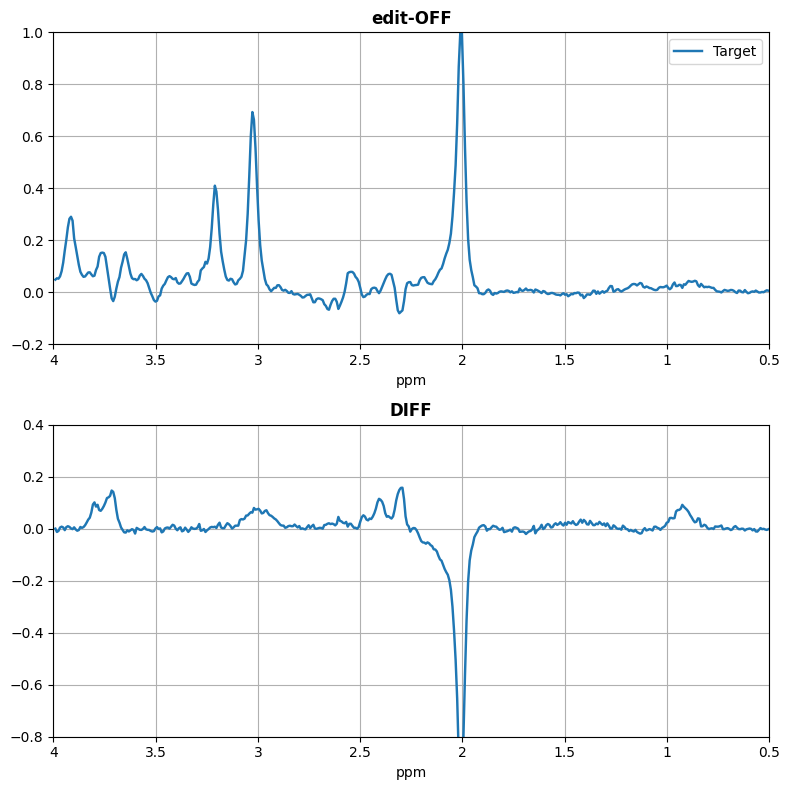

In [13]:
# Visualize input spectra
plot_spectra(input_data[0][sub_num], data.ppm_array[end_idx:start_idx], save_path=f'../saved/input_spectra_{vendor.lower()}_sub-{(sub_num+1):02d}.png')

### Load Basis Set

In [14]:
basisSet = BasisSet.load_h5(f'../basis_sets/basis_{vendor.lower()}_megapress_gaba_te68.h5')

### Build Model

In [17]:
model_weights_path = f'../model_weights/model_weights_CvT.h5' # load model weights for CvT trained on simulated data

In [22]:
cvt_model = build_model(input_shape, input_zf_shape, basisSet, PPMST, PPMEND, low_vals, high_vals, model_weights_path)

In [24]:
# Freeze layers except for the output heads
trainable_heads = {
    "output_amp", "output_global_param", "output_lbL", "output_fr", "output_bl"
}
freeze_layers(cvt_model, trainable_heads)

In [25]:
add_spectral_loss(cvt_model) # add loss function that compares the reconstructed spectrum to the input spectrum
compile_model(cvt_model, lr=1e-4)

In [26]:
cvt_model.summary(line_length=150)

Model: "model_5"
______________________________________________________________________________________________________________________________________________________
 Layer (type)                                Output Shape                                 Param #        Connected to                                 
 input_5 (InputLayer)                        [(None, 457, 2)]                             0              []                                           
                                                                                                                                                      
 conv1d_6 (Conv1D)                           (None, 113, 32)                              480            ['input_5[0][0]']                            
                                                                                                                                                      
 layer_normalization_38 (LayerNormalization  (None, 113, 32)                 

### Train Model

In [27]:
callbacks = build_callbacks()

start_time = time.time() 
history = train_model(cvt_model, input_data[0][sub_num:sub_num+1], input_data[1][sub_num:sub_num+1], batch_size=1, epochs=2500, callbacks=callbacks)
end_time = time.time()

print(f"Time taken: {end_time-start_time:.2f} seconds")

Epoch 1/2500
1/1 [==============================] - 7s 7s/step - loss: 5.4351e-04
Epoch 2/2500
1/1 [==============================] - 0s 49ms/step - loss: 5.0773e-04
Epoch 3/2500
1/1 [==============================] - 0s 41ms/step - loss: 4.7417e-04
Epoch 4/2500
1/1 [==============================] - 0s 44ms/step - loss: 4.4236e-04
Epoch 5/2500
1/1 [==============================] - 0s 39ms/step - loss: 4.1361e-04
Epoch 6/2500
1/1 [==============================] - 0s 49ms/step - loss: 3.8771e-04
Epoch 7/2500
1/1 [==============================] - 0s 50ms/step - loss: 3.6386e-04
Epoch 8/2500
1/1 [==============================] - 0s 44ms/step - loss: 3.4197e-04
Epoch 9/2500
1/1 [==============================] - 0s 36ms/step - loss: 3.2232e-04
Epoch 10/2500
1/1 [==============================] - 0s 37ms/step - loss: 3.0487e-04
Epoch 11/2500
1/1 [==============================] - 0s 55ms/step - loss: 2.8921e-04
Epoch 12/2500
1/1 [==============================] - 0s 45ms/step - loss: 2.

### Make Prediction

In [28]:
prediction = cvt_model.predict([input_data[0][sub_num:sub_num+1], input_data[1][sub_num:sub_num+1]]) # prediction[0] = predicted parameters, prediction[1] = reconstructed spectrum from predicted parameters

1/1 [==============================] - 2s 2s/step


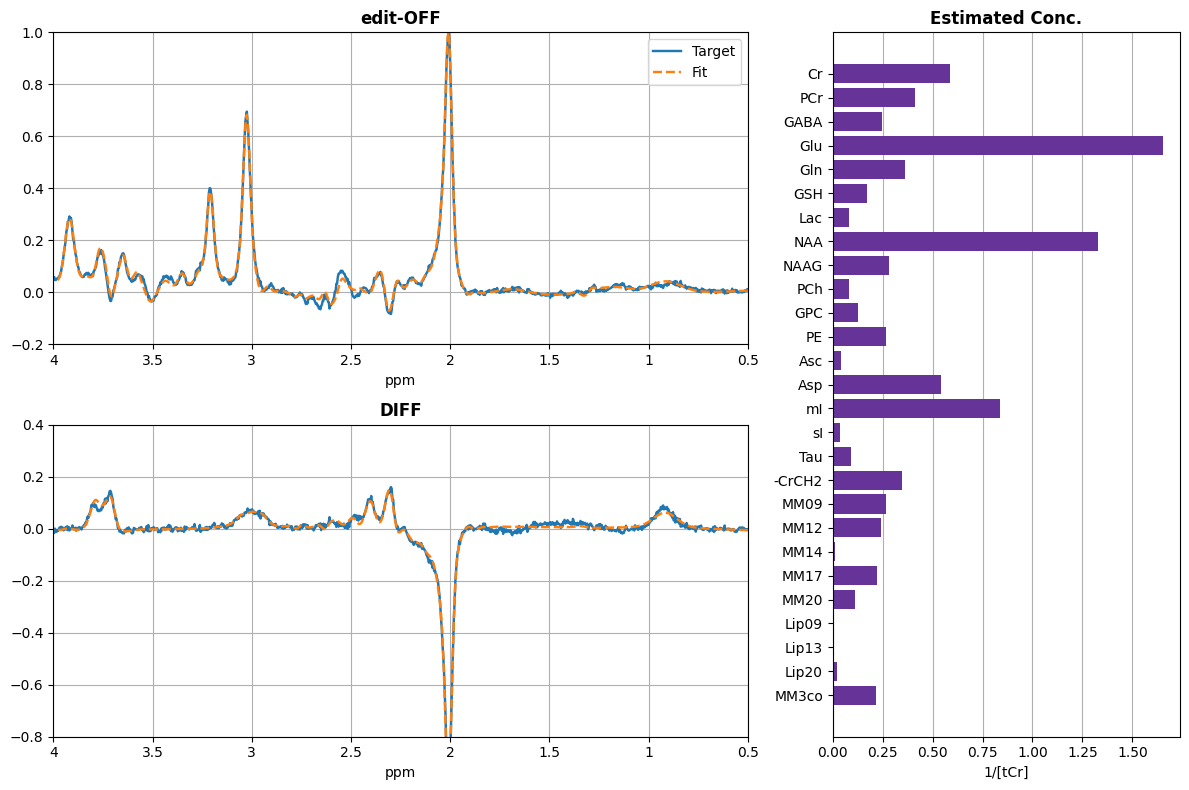

In [29]:
# Visualize fitting results
plot_spectra(target_spectra=input_data[1][sub_num], ppm_array=data.ppm_array_zf[end_idx_zf:start_idx_zf], 
             pred_specs=prediction[1][0], pred_params=prediction[0][0], 
             low_vals=low_vals, high_vals=high_vals, 
             save_path=f'../saved/fitting_results_{vendor.lower()}_sub-{(sub_num+1):02d}.png')